(4)
-> 개봉 월 – 장르 (+배급사)
-> 상영시간( ~80 / ~100/~120 / 120~) – 상영등급(12/15/청불)
-> 총 인력(num_staff + num_actor) - box_off_num / dir_prev_bfnum => 이번 영화의 관객수 / 감독의 평균 관객수(감독의 뛰어남을 보여주는 수치임

해야하는 것

개봉 월 - 장르 : 바이올린 플롯

상영시간 구간별 분리 : valur_counts이용

상영시간 구간별 상영등급 : 히스토그램 이용
(상영시간 자체 별 상영 등급 : scatterplot이용)

총인력 구하기 : 코드를 이용 sum으로

과거의 감독의 평균 관객 대비, 이번 관객 비율 구하기 : 나누기 이용 이것도 코드로만 나타내기

총인력 대비 감독의 성과지표 : 바이올린 플롯 이용

Saving movies_train.csv to movies_train (4).csv


/tmp/ipykernel_183/3290899180.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='genre', y='release_month',data=movies, palette='Set2')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48393 (\N{HANGUL SYLLABLE BONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50900 (\N{HANG

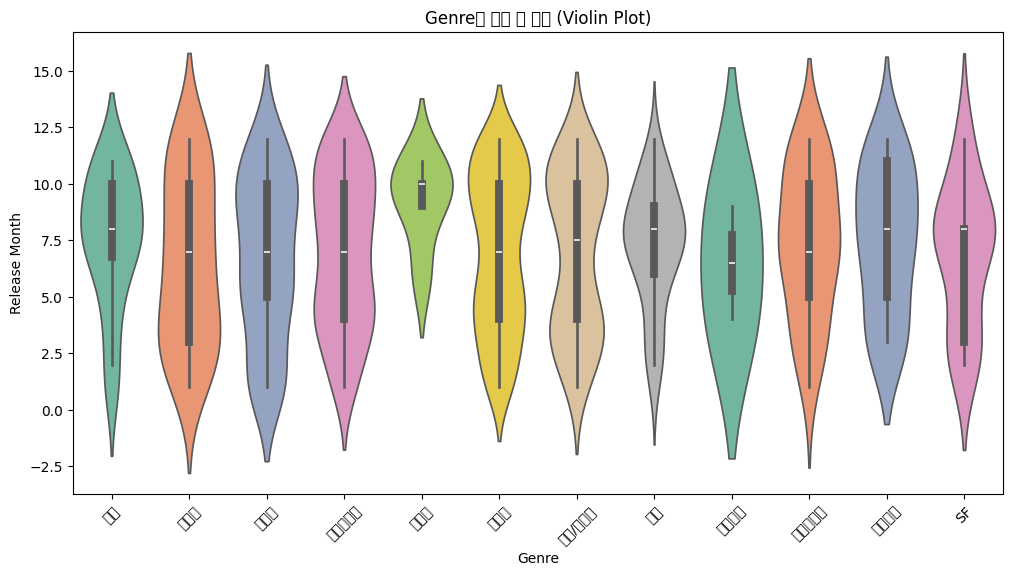

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import files


uploaded = files.upload()
filename = list(uploaded.keys())[0]
movies = pd.read_csv(filename)

#  날짜형 변환
movies['release_time'] = pd.to_datetime(movies['release_time'], errors='coerce')

# 월 정보 추출
movies['release_month'] = movies['release_time'].dt.month

# 결측 제거
movies = movies.dropna(subset=['release_month', 'genre'])

# 시각화
plt.figure(figsize=(12,6))

sns.violinplot(x='genre', y='release_month',data=movies, palette='Set2')

plt.title('Genre별 개봉 월 분포 (Violin Plot)')
plt.xlabel('Genre')
plt.ylabel('Release Month')

plt.xticks(rotation=45)
plt.show()

In [ ]:
import pandas as pd

# 구간 정의
bins = [0, 80, 100, 120, float('inf')]

# 라벨 정의
labels = ['~80', '80~100', '100~120', '120+']

# 구간 나누기
movies['time_group'] = pd.cut(
    movies['time'],
    bins=bins,
    labels=labels,
    right=True  # 오른쪽 포함 (<=)
)

# 확인
movies[['time', 'time_group']].head()

,time,time_group
1,130,120+
2,123,120+
3,101,100~120
4,108,100~120
5,113,100~120


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50689 (\N{HANGUL SYLLABLE YEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr

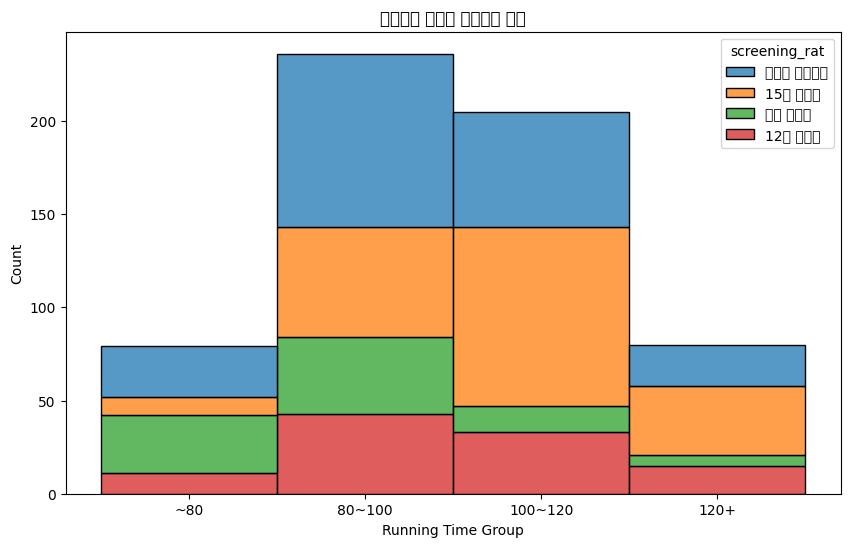

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(data=movies,x='time_group',hue='screening_rat',multiple='stack')  # 쌓아서 보기

plt.title('상영시간 구간별 상영등급 분포')
plt.xlabel('Running Time Group')
plt.ylabel('Count')

plt.show()

In [ ]:
movies['total_people'] = movies['num_staff'] + movies['num_actor']
# 총인력을 나타내는 지표
movies['director_power'] = np.where(movies['dir_prev_bfnum'] == 0, np.nan, movies['box_off_num'] / movies['dir_prev_bfnum'])
#0으로 나누게 되는 경우를 방지 하기 위함



/tmp/ipykernel_183/1412390028.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47141 (\N{HANGUL SYLLABLE RYEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44508 (\N{HANGUL SYLLABLE GYU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  fig.ca

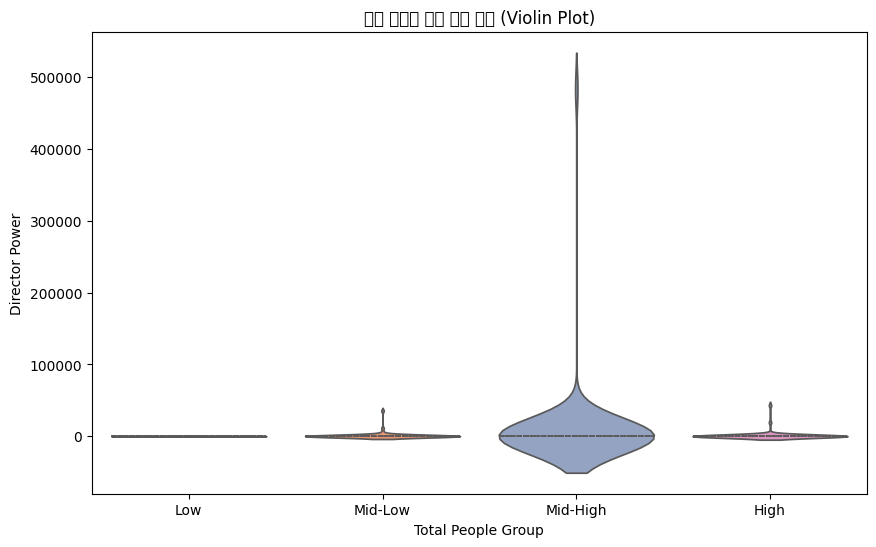

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import files

movies['num_staff'] = pd.to_numeric(movies['num_staff'], errors='coerce')
movies['num_actor'] = pd.to_numeric(movies['num_actor'], errors='coerce')
movies['box_off_num'] = pd.to_numeric(movies['box_off_num'], errors='coerce')
movies['dir_prev_bfnum'] = pd.to_numeric(movies['dir_prev_bfnum'], errors='coerce')

# 5. 파생변수 생성
# (1) 총 인력
movies['total_people'] = movies['num_staff'] + movies['num_actor']
# 총인력을 나타내는 지표
movies['director_power'] = np.where(movies['dir_prev_bfnum'] == 0, np.nan, movies['box_off_num'] / movies['dir_prev_bfnum'])
#0으로 나누게 되는 경우를 방지 하기 위함


# 6. 결측값 제거
movies = movies.dropna(subset=['total_people', 'director_power'])

# 7. total_people 구간화 (4분위 기준)
movies['people_group'] = pd.qcut(
    movies['total_people'],
    q=4,
    labels=['Low', 'Mid-Low', 'Mid-High', 'High']
)

# 8. 바이올린 플롯
plt.figure(figsize=(10,6))

sns.violinplot(
    x='people_group',
    y='director_power',
    data=movies,
    palette='Set2',
    inner='quartile'
)

plt.title('인력 규모별 감독 성과 분포 (Violin Plot)')
plt.xlabel('Total People Group')
plt.ylabel('Director Power')

plt.show()

/tmp/ipykernel_183/2169013084.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47141 (\N{HANGUL SYLLABLE RYEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44508 (\N{HANGUL SYLLABLE GYU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  fig.ca

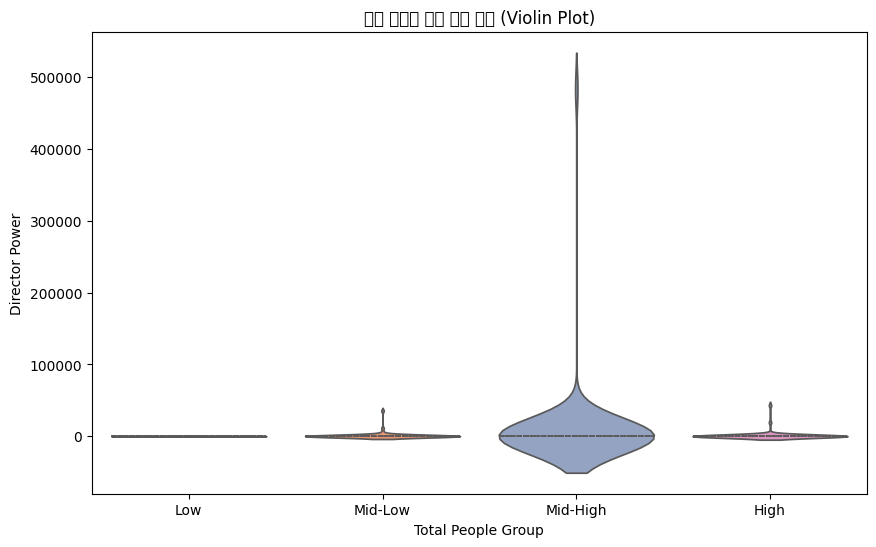

In [ ]:
movies['total_people'] = movies['num_staff'] + movies['num_actor']
# 총인력을 나타내는 지표
movies['director_power'] = np.where(movies['dir_prev_bfnum'] == 0, np.nan, movies['box_off_num'] / movies['dir_prev_bfnum'])
#0으로 나누게 되는 경우를 방지 하기 위함


# 6. 결측값 제거
movies = movies.dropna(subset=['total_people', 'director_power'])

# 7. total_people 구간화 (4분위 기준)
movies['people_group'] = pd.qcut(
    movies['total_people'],
    q=4,
    labels=['Low', 'Mid-Low', 'Mid-High', 'High']
)

# 8. 바이올린 플롯
plt.figure(figsize=(10,6))

sns.violinplot(
    x='people_group',
    y='director_power',
    data=movies,
    palette='Set2',
    inner='quartile'
)

plt.title('인력 규모별 감독 성과 분포 (Violin Plot)')
plt.xlabel('Total People Group')
plt.ylabel('Director Power')

plt.show()